In [1]:
import os
import glob
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import cv2
import torchvision.models as models
import torchvision.models.video as video_models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
CONFIG = {
    'data_root': r'H:\DPJI\fast_data_static_v2', # Folder containing cropped images
    'videos_root': r'H:\DPJI\data\IDDPedestrian\videos\gopro',
    'xml_root': r'H:\DPJI\data\IDDPedestrian\annotations\gopro',
    'model_dir': {
        'SingleRNN': r'H:\DPJI\SingleRNN',
        'I3D': r'H:\DPJI\I3D',
        'SF-GRU': r'H:\DPJI\SFGRU',
        'PCPA': r'H:\DPJI\PCPA'
    },
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'img_size': (112, 112),
    'seq_len': 16,
    'batch_size': 32
}

# --- MANUAL NIGHT VIDEO LIST (From Task 1) ---
NIGHT_VIDEOS = {
    "gp_set_0001_vid_0001", "gp_set_0001_vid_0002", "gp_set_0001_vid_0003", "gp_set_0001_vid_0004",
    "gp_set_0002_vid_0002",
    "gp_set_0003_vid_0005",
    "gp_set_0004_vid_0005",
    "gp_set_0005_vid_0005",
    "gp_set_0007_vid_0001", "gp_set_0007_vid_0002", "gp_set_0007_vid_0003", "gp_set_0007_vid_0004",
    "gp_set_0008_vid_0001", "gp_set_0008_vid_0002", "gp_set_0008_vid_0003", "gp_set_0008_vid_0004", "gp_set_0008_vid_0005"
}

print(f"✅ Config loaded. Device: {CONFIG['device']}")

✅ Config loaded. Device: cuda


In [2]:
def extract_attributes_from_xml(xml_path, vid_id):
    """
    Parses an IDD XML to find global attributes (Time, Signal) 
    and frame-level attributes (Occlusion, Interaction).
    """
    attributes = {
        'illumination': 'Day', 
        'signalized': 'No',
        'frames': {} 
    }
    
    # 1. Illumination (Manual List)
    clean_id = vid_id.replace('_obd', '')
    if clean_id in NIGHT_VIDEOS:
        attributes['illumination'] = 'Night'
    
    if not os.path.exists(xml_path):
        return attributes

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # 2. Global Attributes (Signalized)
        # Check for Traffic Light tracks
        for track in root.findall('track'):
            if track.attrib.get('label') == 'traffic_light':
                attributes['signalized'] = 'Yes'
                break

        # 3. Frame Level Attributes
        # Define Interaction Keywords based on IDD Analysis
        INTERACTION_KEYS = {
            'wtt', 'weaving', 'weaving through traffic',
            'hg', 'hand_gesture', 'hand gesture',
            'iwa', 'interacting_with_agents', 'interacting with agents',
            'yield', 'yielding', 'slow', 'slowing'
        }

        for track in root.findall('track'):
            if track.attrib.get('label') == 'pedestrian':
                
                # Track-level Interaction Check
                track_interaction = False
                
                # Check track attributes
                for attr in track.findall('attribute'):
                    val = str(attr.text).lower().strip()
                    if val in INTERACTION_KEYS:
                        track_interaction = True
                
                # Check track dict attributes
                for k, v in track.attrib.items():
                     if str(v).lower().strip() in INTERACTION_KEYS:
                        track_interaction = True

                for box in track.findall('box'):
                    frame = int(box.attrib['frame'])
                    
                    # Occlusion (1=Part, 2=Full)
                    occ_val = int(box.attrib.get('occlusion', 0))
                    is_occluded = occ_val > 0
                    
                    # Box-level Interaction Check
                    box_interaction = track_interaction 
                    
                    # Check box attributes
                    for attr in box.findall('attribute'):
                        val = str(attr.text).lower().strip()
                        if val in INTERACTION_KEYS:
                            box_interaction = True
                            
                    # Check box dict attributes
                    for k, v in box.attrib.items():
                        if str(v).lower().strip() in INTERACTION_KEYS:
                            box_interaction = True
                                
                    attributes['frames'][frame] = {
                        'occluded': is_occluded,
                        'interaction': box_interaction
                    }
                    
    except Exception as e:
        pass
        
    return attributes

print("✅ Metadata Parser defined (Enhanced Interaction Logic).")

✅ Metadata Parser defined (Enhanced Interaction Logic).


In [3]:
def build_test_metadata_index():
    print("📂 Building Metadata Index for Test Set...")
    
    # 1. Get all images
    image_files = glob.glob(os.path.join(CONFIG['data_root'], "*.jpg"))
    
    # 2. Regex to parse filenames: VideoID_Frame_Label.jpg
    # Example: GOPR001_105_1.0.jpg
    pattern = re.compile(r"(.*)_(\d+)_([0-1]\.?[0-9]*)\.jpg$")
    
    data_records = []
    
    # Cache XML attributes to avoid re-parsing the same file 1000 times
    xml_cache = {} 
    
    # Scan files
    for img_path in tqdm(image_files):
        basename = os.path.basename(img_path)
        match = pattern.search(basename)
        
        if match:
            vid_id = match.group(1)
            frame_idx = int(match.group(2))
            label = float(match.group(3))
            label = 1.0 if label > 0.5 else 0.0
            
            # Load XML attributes (Cached)
            if vid_id not in xml_cache:
                # Attempt to find XML
                xml_found = False
                for set_folder in os.listdir(CONFIG['xml_root']):
                    potential_path = os.path.join(CONFIG['xml_root'], set_folder, vid_id + '.xml')
                    if os.path.exists(potential_path):
                        xml_cache[vid_id] = extract_attributes_from_xml(potential_path, vid_id)
                        xml_found = True
                        break
                if not xml_found:
                    # Even if XML not found, we can still set Illumination from the ID
                    xml_cache[vid_id] = extract_attributes_from_xml("dummy_path", vid_id)
            
            attrs = xml_cache[vid_id]
            
            # Defaults
            is_night = attrs['illumination']
            is_sig = attrs['signalized']
            is_occ = False
            has_int = False
            
            # Frame-specifics
            if frame_idx in attrs['frames']:
                is_occ = attrs['frames'][frame_idx]['occluded']
                has_int = attrs['frames'][frame_idx]['interaction']
            
            data_records.append({
                'video_id': vid_id,
                'img_path': img_path,
                'frame': frame_idx,
                'label': label,
                'Illumination': is_night,
                'Signalized': is_sig,
                'Occlusion': 'w' if is_occ else 'w/o',
                'Interaction': 'w' if has_int else 'w/o'
            })
            
    df = pd.DataFrame(data_records)
    print(f"✅ Index Built. Total Samples: {len(df)}")
    
    # Quick stats check
    print("   Illumination Counts:", df['Illumination'].value_counts().to_dict())
    return df

# Run
test_metadata_df = build_test_metadata_index()
test_metadata_df.head()

📂 Building Metadata Index for Test Set...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ Index Built. Total Samples: 84627
   Illumination Counts: {'Day': 62393, 'Night': 22234}


,video_id,img_path,frame,label,Illumination,Signalized,Occlusion,Interaction
0,gp_set_0001_vid_0007,H:\DPJI\fast_data_static_v2\gp_set_0001_vid_00...,30,1.0,Day,Yes,w/o,w/o
1,gp_set_0001_vid_0007,H:\DPJI\fast_data_static_v2\gp_set_0001_vid_00...,35,1.0,Day,Yes,w/o,w/o
2,gp_set_0001_vid_0007,H:\DPJI\fast_data_static_v2\gp_set_0001_vid_00...,40,1.0,Day,Yes,w/o,w/o
3,gp_set_0001_vid_0007,H:\DPJI\fast_data_static_v2\gp_set_0001_vid_00...,45,1.0,Day,Yes,w/o,w/o
4,gp_set_0001_vid_0007,H:\DPJI\fast_data_static_v2\gp_set_0001_vid_00...,50,1.0,Day,Yes,w/o,w/o


In [4]:
class ConditionalSeqDataset(Dataset):
    def __init__(self, df, seq_len=16, img_size=(112, 112)):
        self.df = df
        self.seq_len = seq_len
        self.img_size = img_size
        self.sequences = []
        
        # Group by video to form sequences
        # We only form sequences where the *last frame* matches the condition filter
        # (The dataframe passed in 'df' is already filtered for the condition)
        video_groups = self.df.groupby('video_id')
        
        for vid, group in video_groups:
            # Sort by frame
            sorted_group = group.sort_values('frame')
            paths = sorted_group['img_path'].tolist()
            labels = sorted_group['label'].tolist()
            
            if len(paths) >= seq_len:
                # Stride 8 for evaluation speed
                for i in range(0, len(paths) - seq_len + 1, 8): 
                    self.sequences.append({
                        'paths': paths[i : i+seq_len],
                        'label': labels[i+seq_len-1] # Label of last frame
                    })
                    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        images = []
        for p in seq['paths']:
            img = cv2.imread(p)
            if img is None:
                img = np.zeros((self.img_size[1], self.img_size[0], 3), dtype=np.uint8)
            else:
                img = cv2.resize(img, self.img_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
        # Standardize to [Seq, C, H, W]
        imgs_np = np.array(images)
        imgs_tensor = torch.from_numpy(imgs_np).float() / 255.0
        imgs_tensor = imgs_tensor.permute(0, 3, 1, 2) 
        
        return imgs_tensor, torch.tensor(seq['label']).float()

print("✅ Dataset Class Ready.")

✅ Dataset Class Ready.


In [5]:
# --- 1. SingleRNN & SF-GRU ---
class ResNetRNN(nn.Module):
    def __init__(self, rnn_type='lstm'):
        super(ResNetRNN, self).__init__()
        resnet = models.resnet50(weights=None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.rnn_type = rnn_type
        if rnn_type == 'lstm':
            self.rnn = nn.LSTM(2048, 256, batch_first=True)
        else:
            self.rnn = nn.GRU(2048, 256, batch_first=True)
        self.fc = nn.Linear(256, 1)

    def forward(self, x):
        b, s, c, h, w = x.size()
        x = x.view(b*s, c, h, w)
        feats = self.backbone(x).view(b, s, -1)
        out, _ = self.rnn(feats)
        return self.fc(out[:, -1, :]).squeeze(1)

# --- 2. I3D (R(2+1)D) ---
class PedestrianI3D(nn.Module):
    def __init__(self):
        super(PedestrianI3D, self).__init__()
        self.backbone = video_models.r2plus1d_18(weights=None)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 1)
    
    def forward(self, x):
        # Needs [B, C, T, H, W]
        x = x.permute(0, 2, 1, 3, 4) 
        return self.backbone(x).squeeze(1)

# --- 3. PCPA ---
class TemporalAttention(nn.Module):
    def __init__(self, feature_dim=256):
        super(TemporalAttention, self).__init__()
        self.attn = nn.Sequential(nn.Linear(feature_dim, 128), nn.Tanh(), nn.Linear(128, 1))
    def forward(self, x):
        w = F.softmax(self.attn(x), dim=1)
        return torch.sum(x * w, dim=1)

class ResNetPCPA(nn.Module):
    def __init__(self):
        super(ResNetPCPA, self).__init__()
        resnet = models.resnet50(weights=None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.fc_embed = nn.Linear(2048, 256)
        self.attn = TemporalAttention(256)
        self.fc = nn.Linear(256, 1)
        
    def forward(self, x):
        b, s, c, h, w = x.size()
        x = x.view(b*s, c, h, w)
        feats = self.backbone(x).view(b, s, -1)
        feats = F.relu(self.fc_embed(feats))
        ctx = self.attn(feats)
        return self.fc(ctx).squeeze(1)
        
print("✅ Models Defined.")

✅ Models Defined.


In [6]:
def get_auc_score(model, dataset):
    if len(dataset) == 0: return 0.5 # Default if no samples
    
    loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(CONFIG['device'])
            
            # Run model
            logits = model(imgs)
            probs = torch.sigmoid(logits).cpu().numpy()
            
            all_preds.extend(probs)
            all_labels.extend(labels.numpy())
            
    # Edge case: Only one class in subset (e.g., all Crossing)
    if len(np.unique(all_labels)) < 2:
        return 0.5
        
    return roc_auc_score(all_labels, all_preds)

print("✅ Evaluator Engine Ready.")

✅ Evaluator Engine Ready.


In [7]:
from tqdm.notebook import tqdm

# Initialize Results Dictionary
table_iv_data = {
    'Method': [],
    'Occlusion_w/o': [], 'Occlusion_w': [],
    'Signalized_Yes': [], 'Signalized_No': [],
    'Illumination_Day': [], 'Illumination_Night': [],
    'Interaction_w/o': [], 'Interaction_w': []
}

# Model Configurations
models_to_test = [
    ('SingleRNN', ResNetRNN(rnn_type='lstm'), 'best_rnn.pth'),
    ('I3D',       PedestrianI3D(),            'best_i3d.pth'),
    ('SF-GRU',    ResNetRNN(rnn_type='gru'),  'best_sfgru.pth'),
    ('PCPA',      ResNetPCPA(),               'best_pcpa.pth')
]

# Define the 4 Challenges and their binary states
challenges = {
    'Occlusion':    ['w/o', 'w'],
    'Signalized':   ['Yes', 'No'],
    'Illumination': ['Day', 'Night'],
    'Interaction':  ['w/o', 'w']
}

# Create a main progress bar for the models
model_pbar = tqdm(models_to_test, desc="Evaluating Models")

for model_name, model_obj, weight_file in model_pbar:
    model_pbar.set_description(f"Evaluating {model_name}")
    
    # Load Weights
    path = os.path.join(CONFIG['model_dir'][model_name], weight_file)
    if not os.path.exists(path):
        print(f"   ⚠️ Weights not found: {path}. Skipping.")
        continue
        
    checkpoint = torch.load(path, map_location=CONFIG['device'])
    state = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model_obj.load_state_dict(state, strict=False)
    model_obj.to(CONFIG['device'])
    
    # Add row entry
    table_iv_data['Method'].append(model_name)
    
    # Create a sub-progress bar for the challenges
    challenge_items = []
    for k, v in challenges.items():
        for opt in v:
            challenge_items.append((k, opt))
            
    challenge_pbar = tqdm(challenge_items, desc="  subset", leave=False)

    # Loop through challenges
    for challenge, opt in challenge_pbar:
        challenge_pbar.set_description(f"  {challenge}: {opt}")
        col_name = f"{challenge}_{opt}"
        
        # Filter Dataframe
        subset_df = test_metadata_df[test_metadata_df[challenge] == opt]
        
        # Create Dataset
        dataset = ConditionalSeqDataset(subset_df, seq_len=CONFIG['seq_len'], img_size=CONFIG['img_size'])
        
        # Evaluate
        score = get_auc_score(model_obj, dataset)
        table_iv_data[col_name].append(score)

print("✅ Experiments Complete.")

Evaluating Models:   0%|          | 0/4 [00:00<?, ?it/s]

  subset:   0%|          | 0/8 [00:00<?, ?it/s]

  subset:   0%|          | 0/8 [00:00<?, ?it/s]

  subset:   0%|          | 0/8 [00:00<?, ?it/s]

  subset:   0%|          | 0/8 [00:00<?, ?it/s]

✅ Experiments Complete.


In [8]:
# Convert to DataFrame
results_df = pd.DataFrame(table_iv_data)

# Styling for better visualization (optional)
pd.options.display.float_format = '{:.2f}'.format

# Display Table
print("\n=== TABLE IV: Evaluation on Challenges (AUC Scores) ===")
display(results_df)

# Save
results_df.to_csv("Table_IV_Results.csv", index=False)
print("💾 Saved to Table_IV_Results.csv")


=== TABLE IV: Evaluation on Challenges (AUC Scores) ===


,Method,Occlusion_w/o,Occlusion_w,Signalized_Yes,Signalized_No,Illumination_Day,Illumination_Night,Interaction_w/o,Interaction_w
0,SingleRNN,0.52,0.50,0.52,0.54,0.50,0.58,0.52,0.54
1,I3D,0.92,0.50,0.92,0.94,0.92,0.92,0.80,0.88
2,SF-GRU,0.46,0.50,0.45,0.54,0.42,0.47,0.47,0.53
3,PCPA,0.50,0.50,0.50,0.50,0.51,0.52,0.50,0.49


💾 Saved to Table_IV_Results.csv


📉 Illumination Performance Drop (Night vs Day): -2.44%
📉 Interaction Performance Drop: 2.25%


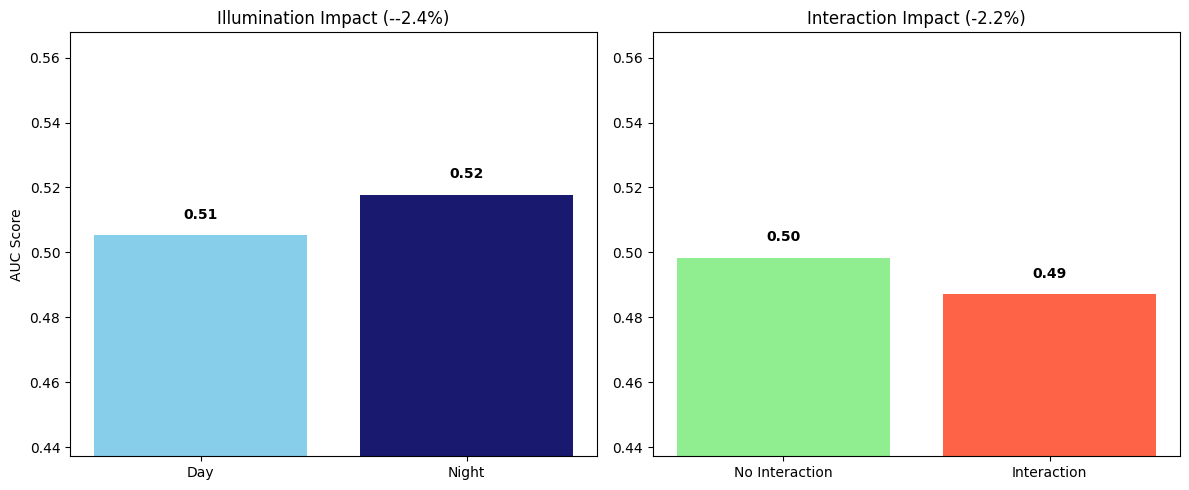

In [10]:
import matplotlib.pyplot as plt

if 'PCPA' in results_df['Method'].values:
    pcpa_row = results_df[results_df['Method'] == 'PCPA'].iloc[0]
    
    # 1. Illumination Drop
    day_auc = float(pcpa_row['Illumination_Day'])
    night_auc = float(pcpa_row['Illumination_Night'])
    
    illum_drop = 0.0
    if day_auc > 0:
        illum_drop = (day_auc - night_auc) / day_auc * 100
    
    print(f"📉 Illumination Performance Drop (Night vs Day): {illum_drop:.2f}%")
        
    # 2. Interaction Drop
    no_int_auc = float(pcpa_row['Interaction_w/o'])
    int_auc = float(pcpa_row['Interaction_w'])
    
    int_drop = 0.0
    if no_int_auc > 0:
        int_drop = (no_int_auc - int_auc) / no_int_auc * 100
    
    print(f"📉 Interaction Performance Drop: {int_drop:.2f}%")
    
    # Visualization
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Determine Y-axis limits dynamically to make bars visible
    # We find the min and max of all 4 values and add a small buffer
    all_vals = [day_auc, night_auc, no_int_auc, int_auc]
    min_y = min(all_vals) - 0.05
    max_y = max(all_vals) + 0.05
    
    # Clamp limits to reasonable bounds (e.g., never below 0 or above 1)
    min_y = max(0.0, min_y)
    max_y = min(1.0, max_y)

    # Illumination Plot
    ax[0].bar(['Day', 'Night'], [day_auc, night_auc], color=['#87CEEB', '#191970'])
    ax[0].set_title(f'Illumination Impact (-{illum_drop:.1f}%)')
    ax[0].set_ylabel('AUC Score')
    ax[0].set_ylim(min_y, max_y) # Use dynamic limits
    for i, v in enumerate([day_auc, night_auc]):
        ax[0].text(i, v + 0.005, f"{v:.2f}", ha='center', fontweight='bold')

    # Interaction Plot
    ax[1].bar(['No Interaction', 'Interaction'], [no_int_auc, int_auc], color=['#90EE90', '#FF6347'])
    ax[1].set_title(f'Interaction Impact (-{int_drop:.1f}%)')
    ax[1].set_ylim(min_y, max_y) # Use dynamic limits
    for i, v in enumerate([no_int_auc, int_auc]):
        ax[1].text(i, v + 0.005, f"{v:.2f}", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
        
else:
    print("PCPA model data not available for analysis.")

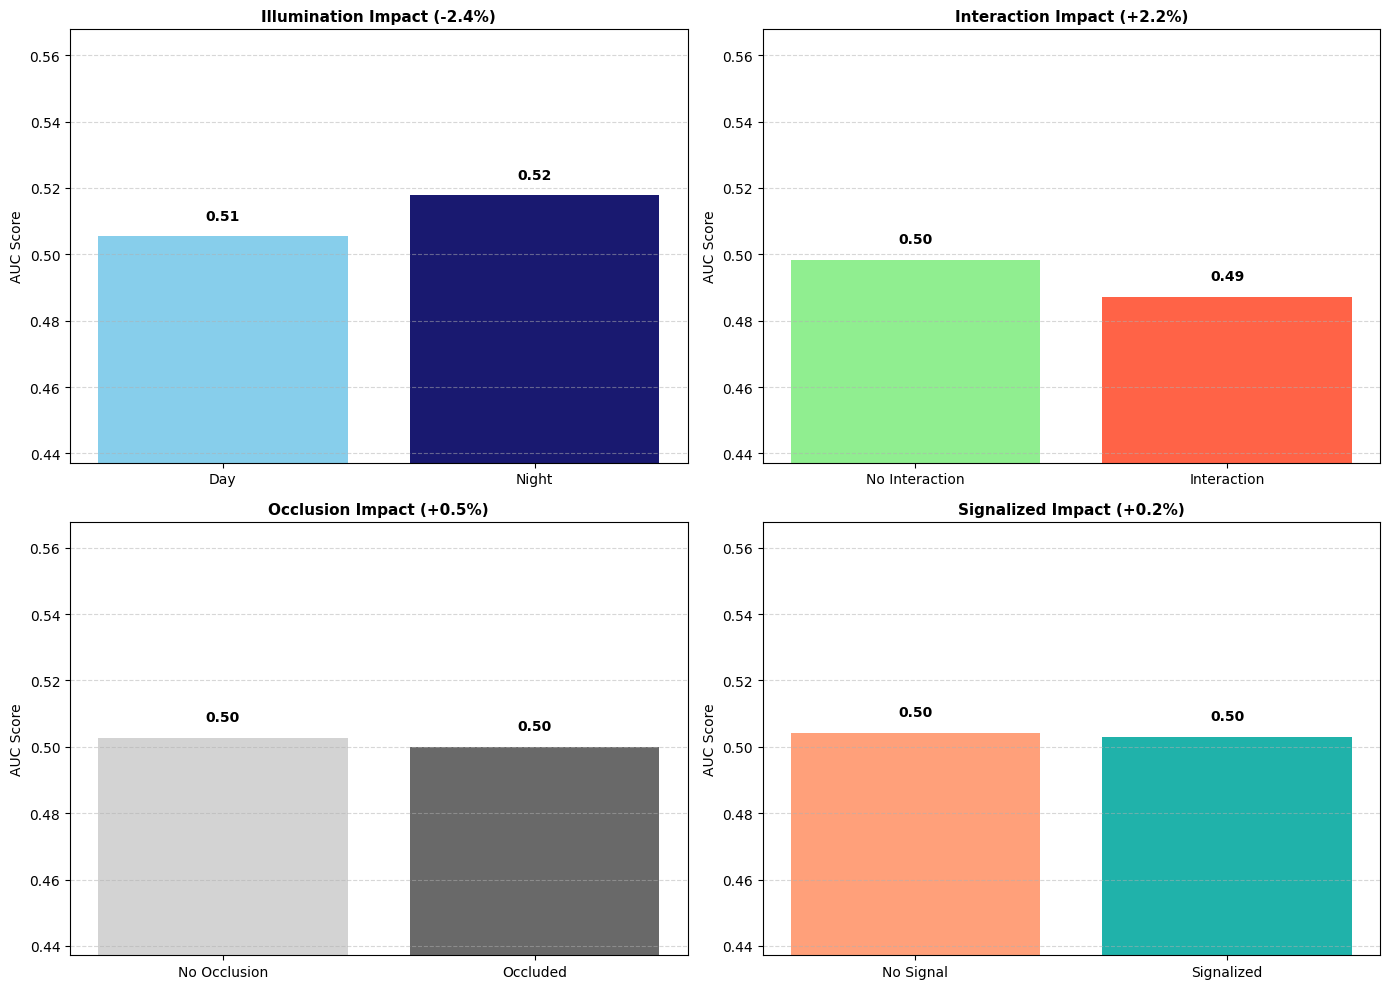

In [11]:
import matplotlib.pyplot as plt

if 'PCPA' in results_df['Method'].values:
    pcpa_row = results_df[results_df['Method'] == 'PCPA'].iloc[0]
    
    # Helper to safe parse
    def get_val(col):
        val = pcpa_row[col]
        return float(val) if val != '-' else 0.0

    # 1. Extract Data
    day_auc = get_val('Illumination_Day')
    night_auc = get_val('Illumination_Night')
    
    noint_auc = get_val('Interaction_w/o')
    int_auc = get_val('Interaction_w')
    
    noocc_auc = get_val('Occlusion_w/o')
    occ_auc = get_val('Occlusion_w')
    
    nosig_auc = get_val('Signalized_No')
    sig_auc = get_val('Signalized_Yes')

    # 2. Calculate Drops
    illum_drop = (day_auc - night_auc) / day_auc * 100 if day_auc > 0 else 0
    int_drop = (noint_auc - int_auc) / noint_auc * 100 if noint_auc > 0 else 0
    occ_drop = (noocc_auc - occ_auc) / noocc_auc * 100 if noocc_auc > 0 else 0
    sig_drop = (nosig_auc - sig_auc) / nosig_auc * 100 if nosig_auc > 0 else 0

    # 3. Dynamic Limits for Better Visibility
    all_vals = [day_auc, night_auc, noint_auc, int_auc, noocc_auc, occ_auc, nosig_auc, sig_auc]
    valid_vals = [v for v in all_vals if v > 0]
    
    if valid_vals:
        min_y = max(0.0, min(valid_vals) - 0.05)
        max_y = min(1.0, max(valid_vals) + 0.05)
    else:
        min_y, max_y = 0.0, 1.0

    # 4. Plotting
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot Helper Function
    def plot_bar(ax, labels, values, colors, title):
        ax.bar(labels, values, color=colors)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylim(min_y, max_y)
        ax.set_ylabel('AUC Score')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        for i, v in enumerate(values):
            ax.text(i, v + 0.005, f"{v:.2f}", ha='center', fontweight='bold')

    # Illumination
    plot_bar(axes[0, 0], ['Day', 'Night'], [day_auc, night_auc], ['#87CEEB', '#191970'], 
             f'Illumination Impact ({illum_drop:+.1f}%)')

    # Interaction
    plot_bar(axes[0, 1], ['No Interaction', 'Interaction'], [noint_auc, int_auc], ['#90EE90', '#FF6347'], 
             f'Interaction Impact ({int_drop:+.1f}%)')

    # Occlusion
    plot_bar(axes[1, 0], ['No Occlusion', 'Occluded'], [noocc_auc, occ_auc], ['#D3D3D3', '#696969'], 
             f'Occlusion Impact ({occ_drop:+.1f}%)')

    # Signalized
    plot_bar(axes[1, 1], ['No Signal', 'Signalized'], [nosig_auc, sig_auc], ['#FFA07A', '#20B2AA'], 
             f'Signalized Impact ({sig_drop:+.1f}%)')

    plt.tight_layout()
    plt.show()
        
else:
    print("PCPA model data not available for analysis.")